In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/zalando-research
/kaggle/input/datasets/organizations/zalando-research/fashionmnist


In [7]:
dataset_path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist"

train_file = dataset_path + "/fashion-mnist_train.csv"
test_file = dataset_path + "/fashion-mnist_test.csv"

In [8]:
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
print(train_df.shape)
print(test_df.shape)

(60000, 785)
(10000, 785)


In [10]:
kelas = [0,1,7]

train_df = train_df[train_df["label"].isin(kelas)]
test_df = test_df[test_df["label"].isin(kelas)]

In [11]:
mapping = {0:0,1:1,7:2}

train_df["label"] = train_df["label"].map(mapping)
test_df["label"] = test_df["label"].map(mapping)

In [12]:
X_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

X_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values

In [13]:
X_train = X_train/255.0
X_test = X_test/255.0

In [14]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

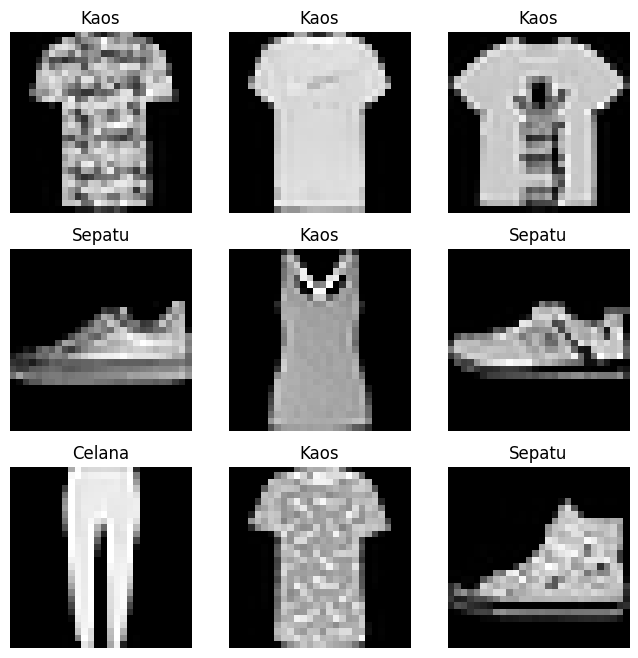

In [15]:
kelas = ["Kaos","Celana","Sepatu"]

plt.figure(figsize=(8,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i].reshape(28,28),cmap="gray")

    plt.title(kelas[y_train[i]])

    plt.axis("off")

In [17]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3,activation='softmax')
])

In [18]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [19]:
history=model.fit(
X_train,
y_train,
epochs=10,
batch_size=32,
validation_split=0.2
)

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9795 - loss: 0.0639 - val_accuracy: 0.9908 - val_loss: 0.0289
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9938 - loss: 0.0217 - val_accuracy: 0.9933 - val_loss: 0.0201
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9950 - loss: 0.0152 - val_accuracy: 0.9950 - val_loss: 0.0183
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9961 - loss: 0.0106 - val_accuracy: 0.9939 - val_loss: 0.0229
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9968 - loss: 0.0105 - val_accuracy: 0.9936 - val_loss: 0.0211
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9976 - loss: 0.0070 - val_accuracy: 0.9956 - val_loss: 0.0190
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.9944 - val_loss: 0.0231
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9978 - loss: 0.0057 - val_acc

In [20]:
loss,acc=model.evaluate(X_test,y_test)

print("Accuracy :",acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9967 - loss: 0.0129
Accuracy : 0.996666669845581


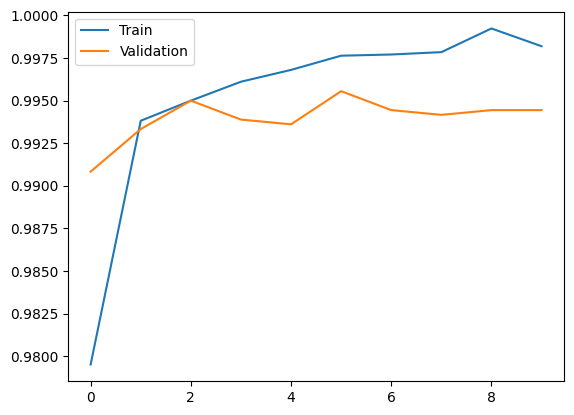

In [21]:

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.show()

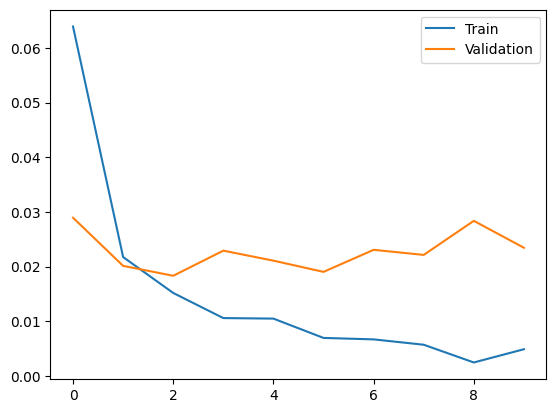

In [22]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.show()

In [36]:
class_names = ["Kaos", "Celana", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sepatu", "Bag", "Boot"]

In [37]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
X_sample = X_test[:9]
y_true = y_test[:9]

In [39]:
pred = model.predict(X_sample)

y_pred = np.argmax(pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


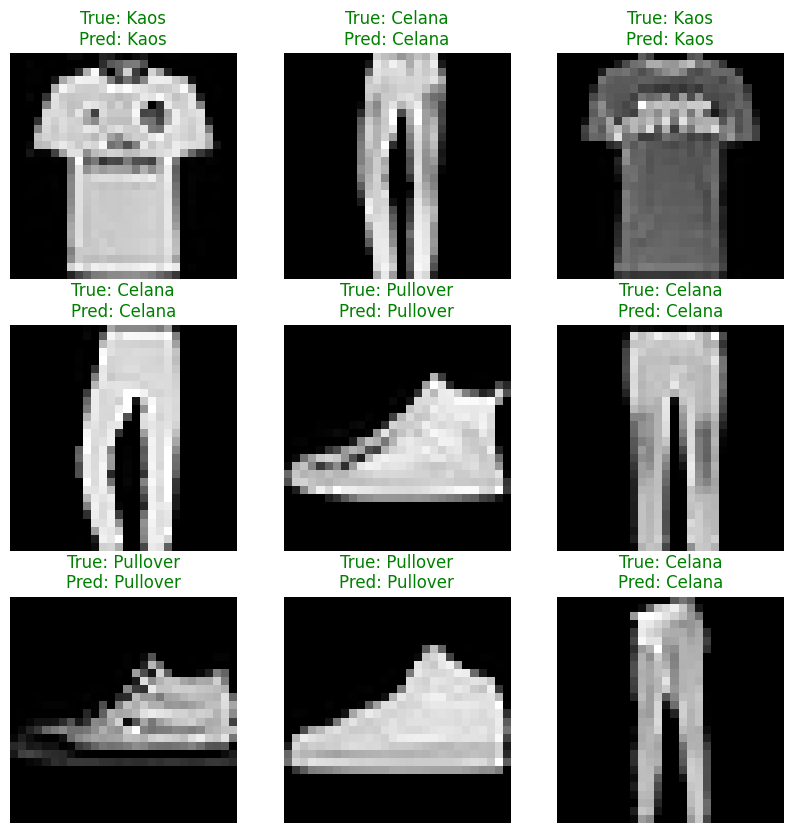

In [40]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_sample[i].reshape(28,28), cmap='gray')

    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]

    color = "green" if true_label == pred_label else "red"

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)

    plt.axis("off")

plt.show()

In [41]:
for i in range(9):
    print(f"Data {i+1}")
    print("True :", class_names[y_true[i]])
    print("Pred :", class_names[y_pred[i]])
    print("-"*30)

Data 1
True : Kaos
Pred : Kaos
------------------------------
Data 2
True : Celana
Pred : Celana
------------------------------
Data 3
True : Kaos
Pred : Kaos
------------------------------
Data 4
True : Celana
Pred : Celana
------------------------------
Data 5
True : Pullover
Pred : Pullover
------------------------------
Data 6
True : Celana
Pred : Celana
------------------------------
Data 7
True : Pullover
Pred : Pullover
------------------------------
Data 8
True : Pullover
Pred : Pullover
------------------------------
Data 9
True : Celana
Pred : Celana
------------------------------
